### Imports

In [1209]:
import json
import os
import pandas as pd

from utils_MS import *

# %load_ext autotime

In [1210]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import plotly.graph_objects as go
import sys
import torch
import torch.nn.functional as F
import os.path as osp

%matplotlib inline
from IPython import display
from IPython.display import HTML
from matplotlib import animation

from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.data import Data
from torch import nn, optim, Tensor
from torch_geometric.utils import structured_negative_sampling, to_networkx
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import LGConv, Node2Vec, GCNConv, GATv2Conv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout
import torch_geometric.transforms as T

from tqdm import tqdm

In [1211]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

In [1212]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [1213]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import kneighbors_graph

In [1214]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

In [1215]:
# def run(params):

### Parameters

In [1216]:
""" try:
    dir = os.path.dirname(os.path.abspath(__file__))
except:
    dir = os.getcwd()
print(dir) """

' try:\n    dir = os.path.dirname(os.path.abspath(__file__))\nexcept:\n    dir = os.getcwd()\nprint(dir) '

In [1217]:
dict_dataset = {
    1: ["Mentos_2_process_NormalizationFiltered_format", ["Orange"]], # new mentos,  for Metabolomics
    2: ["deybis_filter_september_2br_3ar_format", ["SecoAmazonas"]],
    3: ["deybis_filter_december_2br_3ar_format", ["SecoAmazonas"]],
    4: ["deybis_filter_september_2br_10ar_format", ["SecoAmazonas"]],
    5: ["deybis_filter_december_2br_10ar_format", ["SecoAmazonas"]], # for Metabolomics
    6: ["deybis_filter_september_min_2br_3ar_format", ["SecoAmazonas"]],
    7: ["deybis_filter_december_min_2br_3ar_format", ["SecoAmazonas"]],
    8: ["vanessa_december_2br_3ar_format", ["SecoAmazonas"]],
    9: ["Pablo_2br_nar_format", ["AR"]],
    10: ["Pablo_2br_14ar_format", ["AR"]],
}
dataset = dict_dataset[9] # change
dataset

['Pablo_2br_nar_format', ['AR']]

In [1218]:
params = {
    "exp": "exp0", # Change
    "methods": ["t-gae"], # ["vgae-base", "argva-base", "vgae-line", "dgi-tran", "t-gae"],
    "data_variations": ["none"],
    "has_transformation": True, # True or False
    "controls": dataset[1],
    "dimension": 64,
    "threshold_corr": 0.5,
    "threshold_log2": 0,
    "alpha": 0.05,
    "iterations": 1,
    "raw_data_file": dataset[0],
    "groups_id_no": ["Blank", "QC", "Std"],
    "sensitivity": False, # False: f1 (selectivity), True: f1 (selectivity), f2 (sensitivity)
    "obs": "",
    "seeds": [41, 42, 43, 44, 45, 46],
    
    "from": "python",
    "cuda": 0,
    "epochs": 100,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "patience": 10,
    "contamination": 0.1, # float in (0., 0.5)
    "n_jobs": 1, # -1 all
}

In [1219]:
""" dir_path = "experiments/output"
res = sorted(os.listdir(dir_path))
n = len(res)
exp = "exp{}".format(n) """

exp = str(params["exp"])
exp

'exp0'

### Load dataset

In [1220]:
exp = "exp8"
file = open("experiments/output/{}/parameters.json".format(exp))
params = json.load(file)

exp = params["exp"]

print("Exp:\t\t", exp)

methods = params["methods"]
print("Methods:\t", methods)

data_variations = params["data_variations"]
print("Data variations:", data_variations)

controls = params["controls"]
print("Control:\t", controls)

groups_id = params["groups_id"]
# groups_id = ['SecoAmazonas', 'SecoCusco', 'SecoSanMartin', 'FrescoAmazonas', 'FrescoCusco', 'FrescoSanMartin']
print("Groups id:\t", groups_id)

subgroups_id = params["subgroups_id"]
print("Subgroups id:\t", subgroups_id)

groups = params["groups"]
print("Groups:\t\t", groups)

# encoders = ["GIN", "GINE"]
encoders = ["GIN"]

Exp:		 exp8
Methods:	 ['t-gae']
Data variations: ['none']
Control:	 ['AR']
Groups id:	 ['AR', 'CRS', 'OSA', 'LPRD', 'SGB', 'LSNB', 'RCC', 'BC', 'BPH', 'PCa', 'PD']
Subgroups id:	 {'AR': ['1', '2'], 'CRS': ['1', '2'], 'OSA': ['1', '2'], 'LPRD': ['1', '2'], 'SGB': ['1', '2'], 'LSNB': ['1', '2'], 'RCC': ['1', '2'], 'BC': ['1', '2'], 'BPH': ['1', '2'], 'PCa': ['1', '2'], 'PD': ['1', '2']}
Groups:		 [['AR', 'CRS'], ['AR', 'OSA'], ['AR', 'LPRD'], ['AR', 'SGB'], ['AR', 'LSNB'], ['AR', 'RCC'], ['AR', 'BC'], ['AR', 'BPH'], ['AR', 'PCa'], ['AR', 'PD']]


In [1221]:
params["raw_data_file"] = "Pablo_2br_nar_format" # Obs

In [1222]:
# load dataset groups
if params["from"] == "python":
    df_raw = pd.read_csv("experiments/raw_data/{}.csv".format(params["raw_data_file"]), delimiter="|")
elif params["from"] == "drf":
    df_raw = pd.read_csv("{}".format(params["raw_data_file"]), delimiter="|") # from DRF
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


### Format dataset

In [1223]:
# has transformation
""" columns_data = list(df_raw.columns)[4:]
if params["has_transformation"]:
    print("transformation")
    for column in columns_data:
        df_raw[column] = df_raw[column].apply(lambda x: 10**x)
df_raw """

' columns_data = list(df_raw.columns)[4:]\nif params["has_transformation"]:\n    print("transformation")\n    for column in columns_data:\n        df_raw[column] = df_raw[column].apply(lambda x: 10**x)\ndf_raw '

In [1224]:
# concat
df_join_raw = pd.concat([
    df_raw.iloc[:, :]], axis=1)
df_join_raw.set_index("Alignment ID", inplace=True)
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
Alignment ID,,,,,,,,,,,,,,,,,,,,,
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369


In [1225]:
# split
df_join_raw = df_join_raw.rename_axis(None)
# df_join_raw = df_join_raw.iloc[:, 2:]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [1226]:
# Filter node id (get common node id)
for encoder in encoders:
	for group_id in groups_id + ["union", "intersection"]:
		# Read common node
		common_node_id = np.load(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.npy")
		print(group_id, len(common_node_id)) #, common_node_id)


AR 23
CRS 51
OSA 32
LPRD 55
SGB 11
LSNB 77
RCC 28
BC 26
BPH 13
PCa 27
PD 28
union 345
intersection 0


In [1227]:
group_id = "union" # "AR" # Change
common_node_id = np.load(f"experiments/output/{exp}/common_nodes/{encoder}_{group_id}.npy")

df_join_raw = df_join_raw.loc[common_node_id]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
3072,1.0,217.14343,Unknown,4.448470,4.636063,4.705550,4.229507,4.474201,4.595985,4.564126,...,3.515879,4.655424,4.505656,4.877023,3.948441,4.629174,4.375918,4.861519,3.580755,4.377145
5122,1.0,373.09805,Unknown,5.258354,5.485484,5.479483,5.491300,5.222411,5.330415,5.294289,...,5.299280,5.297026,5.129695,5.221422,5.523984,5.176126,6.101565,6.063022,6.710662,6.850332
1026,1.0,133.01722,Unknown,3.747354,3.660482,4.283223,3.885742,3.605903,3.612503,3.841110,...,2.742990,3.291870,3.871651,3.561956,2.809524,3.210722,3.147984,3.693127,2.963590,2.797572
3077,1.0,217.17982,Unknown,5.082521,5.159848,4.932096,4.674484,4.714564,4.952885,4.883848,...,4.645517,5.183908,4.803662,5.280668,4.724810,5.348147,4.559819,5.253153,4.637466,5.328960
5127,1.0,373.96428,Unknown,-0.312569,-1.093034,3.142400,-0.773451,-0.684887,-0.614605,-0.556089,...,-0.766233,3.408366,1.157124,2.725741,-0.506380,-0.694769,-0.592521,2.760075,-0.595404,-0.691628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,1.0,174.01549,Unknown,0.023985,-1.562819,-1.348860,-1.218144,-1.122627,-1.046827,-0.983716,...,-0.857745,-0.730518,-0.226158,-0.719781,-0.234996,-0.741305,-0.475540,-0.714431,-0.490117,-0.735905
4071,1.0,267.21475,Unknown,1.526544,-0.947225,-0.798143,-0.640509,-0.587693,-0.543719,-0.505933,...,-0.735712,-0.680897,1.278688,1.799632,-0.515230,-0.686831,-0.612402,-0.677944,1.849813,-0.683859
5106,1.0,370.91487,Unknown,1.145523,2.063139,2.263808,2.177127,2.146144,2.741921,2.233036,...,0.421030,0.526989,0.879426,3.879926,0.870412,0.514362,0.751116,0.533242,0.735883,0.520696
2038,1.0,174.93461,Unknown,2.582367,0.900924,1.150365,1.414117,1.502486,1.576063,1.639286,...,1.824945,1.930891,2.349012,1.939478,2.341842,1.922269,2.204549,1.943758,2.131944,1.926584


In [1228]:
# get metadata
df_join_raw_metadata = df_join_raw.iloc[:, :2]
df_join_raw_metadata

,Average Rt,Average Mz
3072,1.0,217.14343
5122,1.0,373.09805
1026,1.0,133.01722
3077,1.0,217.17982
5127,1.0,373.96428
...,...,...
2019,1.0,174.01549
4071,1.0,267.21475
5106,1.0,370.91487
2038,1.0,174.93461


In [1229]:
df_join_raw_intensity = df_join_raw.iloc[:, 3:]
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
3072,4.448470,4.636063,4.705550,4.229507,4.474201,4.595985,4.564126,4.452673,4.640618,4.367397,...,3.515879,4.655424,4.505656,4.877023,3.948441,4.629174,4.375918,4.861519,3.580755,4.377145
5122,5.258354,5.485484,5.479483,5.491300,5.222411,5.330415,5.294289,5.243430,5.240660,5.320868,...,5.299280,5.297026,5.129695,5.221422,5.523984,5.176126,6.101565,6.063022,6.710662,6.850332
1026,3.747354,3.660482,4.283223,3.885742,3.605903,3.612503,3.841110,3.925053,3.997461,3.866673,...,2.742990,3.291870,3.871651,3.561956,2.809524,3.210722,3.147984,3.693127,2.963590,2.797572
3077,5.082521,5.159848,4.932096,4.674484,4.714564,4.952885,4.883848,4.999142,4.924139,4.605312,...,4.645517,5.183908,4.803662,5.280668,4.724810,5.348147,4.559819,5.253153,4.637466,5.328960
5127,-0.312569,-1.093034,3.142400,-0.773451,-0.684887,-0.614605,-0.556089,-0.505807,-0.353786,4.440441,...,-0.766233,3.408366,1.157124,2.725741,-0.506380,-0.694769,-0.592521,2.760075,-0.595404,-0.691628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,0.023985,-1.562819,-1.348860,-1.218144,-1.122627,-1.046827,-0.983716,-0.929487,-0.765530,2.651200,...,-0.857745,-0.730518,-0.226158,-0.719781,-0.234996,-0.741305,-0.475540,-0.714431,-0.490117,-0.735905
4071,1.526544,-0.947225,-0.798143,-0.640509,-0.587693,-0.543719,-0.505933,-0.472733,-0.391692,-0.328447,...,-0.735712,-0.680897,1.278688,1.799632,-0.515230,-0.686831,-0.612402,-0.677944,1.849813,-0.683859
5106,1.145523,2.063139,2.263808,2.177127,2.146144,2.741921,2.233036,2.346306,2.398403,1.652961,...,0.421030,0.526989,0.879426,3.879926,0.870412,0.514362,0.751116,0.533242,0.735883,0.520696
2038,2.582367,0.900924,1.150365,1.414117,1.502486,1.576063,1.639286,1.694836,1.868287,1.967056,...,1.824945,1.930891,2.349012,1.939478,2.341842,1.922269,2.204549,1.943758,2.131944,1.926584


In [1230]:
# get 100 first AR
df_join_raw_intensity = df_join_raw.iloc[:, 363:]
df_join_raw_intensity

,AR_2.131,AR_2.132,AR_2.133,AR_2.134,AR_2.135,AR_2.136,AR_2.137,AR_2.138,AR_2.139,AR_2.140,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
3072,5.130166,5.343628,5.317453,5.070158,5.267546,4.791498,4.826269,4.709920,4.901736,4.663130,...,3.515879,4.655424,4.505656,4.877023,3.948441,4.629174,4.375918,4.861519,3.580755,4.377145
5122,5.023015,5.214261,4.504189,4.882667,4.827848,5.628397,5.379179,5.029880,5.413043,4.889224,...,5.299280,5.297026,5.129695,5.221422,5.523984,5.176126,6.101565,6.063022,6.710662,6.850332
1026,3.973825,3.185309,3.335007,3.552610,4.014149,3.590505,2.570359,3.350594,3.360789,2.905322,...,2.742990,3.291870,3.871651,3.561956,2.809524,3.210722,3.147984,3.693127,2.963590,2.797572
3077,5.170928,5.450149,5.500358,5.041154,5.545196,5.294520,5.126694,5.038237,5.223161,5.022871,...,4.645517,5.183908,4.803662,5.280668,4.724810,5.348147,4.559819,5.253153,4.637466,5.328960
5127,-0.078472,2.151233,-0.076437,2.551387,-0.074404,-0.060242,-0.052200,1.711733,-0.046193,-0.042199,...,-0.766233,3.408366,1.157124,2.725741,-0.506380,-0.694769,-0.592521,2.760075,-0.595404,-0.691628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,0.642668,3.972674,2.524512,0.649303,0.652617,0.679046,0.688919,0.692206,0.705330,0.711879,...,-0.857745,-0.730518,-0.226158,-0.719781,-0.234996,-0.741305,-0.475540,-0.714431,-0.490117,-0.735905
4071,-0.296947,-0.294894,1.884207,2.618649,1.758578,1.886468,-0.284679,-0.282646,-0.280616,1.985983,...,-0.735712,-0.680897,1.278688,1.799632,-0.515230,-0.686831,-0.612402,-0.677944,1.849813,-0.683859
5106,1.577677,1.580361,1.583041,2.734886,1.588387,3.477108,1.606966,3.286745,3.577443,3.896404,...,0.421030,0.526989,0.879426,3.879926,0.870412,0.514362,0.751116,0.533242,0.735883,0.520696
2038,3.133821,3.136552,3.139282,3.144736,3.147460,3.169196,3.180026,3.182729,3.193528,3.198917,...,1.824945,1.930891,2.349012,1.939478,2.341842,1.922269,2.204549,1.943758,2.131944,1.926584


In [1231]:
# get groups name
groups_id = []
for item in df_join_raw_intensity.columns.values:
    group_id = item.split("_")[0]
    groups_id.append(group_id)
print(groups_id)

['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 

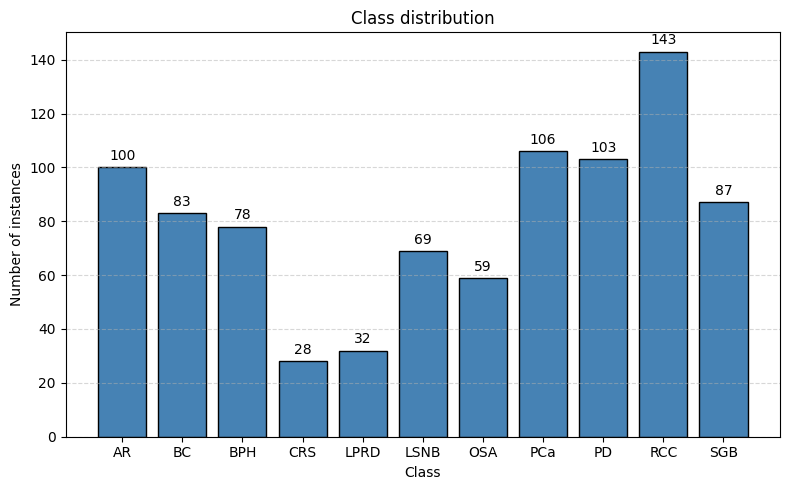

In [1232]:
def plot_class_distribution(labels, class_names=None):
    """
    Plot the number of instances per class.

    Parameters
    ----------
    labels : array-like
        List or array of class labels.
    class_names : dict or list, optional
        Mapping from class id to class name.
    """
    labels = np.asarray(labels)

    # Count instances per class
    classes, counts = np.unique(labels, return_counts=True)

    # X-axis labels
    if class_names is None:
        x_labels = [str(c) for c in classes]
    elif isinstance(class_names, dict):
        x_labels = [class_names[c] for c in classes]
    else:
        x_labels = [class_names[c] for c in classes]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        x_labels,
        counts,
        color="steelblue",
        edgecolor="black"
    )

    # Display values on top of bars
    ax.bar_label(
        bars,
        fmt="%d",
        padding=3,
        fontsize=10,
        # fontweight="bold"
    )

    ax.set_xlabel("Class")
    ax.set_ylabel("Number of instances")
    ax.set_title("Class distribution")

    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_class_distribution(groups_id)

### Classification

#### Data preparation

In [1233]:
df_join_raw_intensity

,AR_2.131,AR_2.132,AR_2.133,AR_2.134,AR_2.135,AR_2.136,AR_2.137,AR_2.138,AR_2.139,AR_2.140,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
3072,5.130166,5.343628,5.317453,5.070158,5.267546,4.791498,4.826269,4.709920,4.901736,4.663130,...,3.515879,4.655424,4.505656,4.877023,3.948441,4.629174,4.375918,4.861519,3.580755,4.377145
5122,5.023015,5.214261,4.504189,4.882667,4.827848,5.628397,5.379179,5.029880,5.413043,4.889224,...,5.299280,5.297026,5.129695,5.221422,5.523984,5.176126,6.101565,6.063022,6.710662,6.850332
1026,3.973825,3.185309,3.335007,3.552610,4.014149,3.590505,2.570359,3.350594,3.360789,2.905322,...,2.742990,3.291870,3.871651,3.561956,2.809524,3.210722,3.147984,3.693127,2.963590,2.797572
3077,5.170928,5.450149,5.500358,5.041154,5.545196,5.294520,5.126694,5.038237,5.223161,5.022871,...,4.645517,5.183908,4.803662,5.280668,4.724810,5.348147,4.559819,5.253153,4.637466,5.328960
5127,-0.078472,2.151233,-0.076437,2.551387,-0.074404,-0.060242,-0.052200,1.711733,-0.046193,-0.042199,...,-0.766233,3.408366,1.157124,2.725741,-0.506380,-0.694769,-0.592521,2.760075,-0.595404,-0.691628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,0.642668,3.972674,2.524512,0.649303,0.652617,0.679046,0.688919,0.692206,0.705330,0.711879,...,-0.857745,-0.730518,-0.226158,-0.719781,-0.234996,-0.741305,-0.475540,-0.714431,-0.490117,-0.735905
4071,-0.296947,-0.294894,1.884207,2.618649,1.758578,1.886468,-0.284679,-0.282646,-0.280616,1.985983,...,-0.735712,-0.680897,1.278688,1.799632,-0.515230,-0.686831,-0.612402,-0.677944,1.849813,-0.683859
5106,1.577677,1.580361,1.583041,2.734886,1.588387,3.477108,1.606966,3.286745,3.577443,3.896404,...,0.421030,0.526989,0.879426,3.879926,0.870412,0.514362,0.751116,0.533242,0.735883,0.520696
2038,3.133821,3.136552,3.139282,3.144736,3.147460,3.169196,3.180026,3.182729,3.193528,3.198917,...,1.824945,1.930891,2.349012,1.939478,2.341842,1.922269,2.204549,1.943758,2.131944,1.926584


In [1234]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,3072,5122,1026,3077,5127,1032,8,4107,2065,1042,...,1994,3020,4060,992,3040,2019,4071,5106,2038,4088
AR_2.131,5.130166,5.023015,3.973825,5.170928,-0.078472,3.570346,1.514461,3.714534,2.178250,5.601956,...,3.087355,4.434302,2.539398,5.234197,3.939224,0.642668,-0.296947,1.577677,3.133821,-0.349213
AR_2.132,5.343628,5.214261,3.185309,5.450149,2.151233,3.252927,1.515152,4.862798,2.180609,5.886869,...,0.868688,4.672941,2.620812,5.235591,4.083868,3.972674,-0.294894,1.580361,3.136552,-0.346635
AR_2.133,5.317453,4.504189,3.335007,5.500358,-0.076437,3.309953,2.700345,3.391382,2.767318,5.391767,...,0.871968,4.493782,2.411913,5.014199,4.048461,2.524512,1.884207,1.583041,3.139282,1.507120
AR_2.134,5.070158,4.882667,3.552610,5.041154,2.551387,3.530824,2.696647,3.395092,2.185318,5.288866,...,0.878522,4.445350,2.541182,4.997008,4.107328,0.649303,2.618649,2.734886,3.144736,1.524976
AR_2.135,5.267546,4.827848,4.014149,5.545196,-0.074404,2.903310,2.468783,3.396943,2.187669,5.661263,...,0.881796,4.577336,2.545580,5.294633,4.175661,0.652617,1.758578,1.588387,3.147460,-0.341495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PD_2.48,4.629174,5.176126,3.210722,5.348147,-0.694769,1.802637,1.490460,4.514401,1.287676,5.832258,...,-0.611793,4.448713,1.964852,5.352844,3.905636,-0.741305,-0.686831,0.514362,1.922269,2.476524
PD_2.49,4.375918,6.101565,3.147984,4.559819,-0.592521,2.403645,1.518535,2.821858,1.466230,5.672577,...,-0.340107,4.034962,2.093501,4.685044,3.381617,-0.475540,-0.612402,0.751116,2.204549,2.721286
PD_2.50,4.861519,6.063022,3.693127,5.253153,2.760075,3.508977,3.177941,2.672112,1.309898,5.527432,...,-0.585312,4.274298,1.978055,4.909329,3.802172,-0.714431,-0.677944,0.533242,1.943758,2.684167
PD_2.51,3.580755,6.710662,2.963590,4.637466,-0.595404,1.823644,1.517598,2.811304,1.454604,5.823318,...,-0.354444,3.985916,2.088688,4.809423,2.555082,-0.490117,1.849813,0.735883,2.131944,-0.969165


In [1235]:
print(len(groups_id), groups_id)

888 ['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'CRS', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OSA', 'OS

In [1236]:
X = df_join_raw_intensity_t.values
X

array([[ 5.13016579,  5.0230154 ,  3.97382524, ...,  1.577677  ,
         3.1338214 , -0.34921315],
       [ 5.34362828,  5.21426117,  3.18530933, ...,  1.580361  ,
         3.13655246, -0.34663498],
       [ 5.31745318,  4.50418922,  3.33500694, ...,  1.58304068,
         3.13928185,  1.50711973],
       ...,
       [ 4.86151904,  6.06302239,  3.69312715, ...,  0.53324174,
         1.94375763,  2.6841666 ],
       [ 3.58075506,  6.71066212,  2.96358962, ...,  0.73588304,
         2.13194355, -0.9691646 ],
       [ 4.37714525,  6.8503317 ,  2.79757227, ...,  0.52069596,
         1.9265842 , -1.01205228]])

In [1237]:
# Convertir a serie de categorías y obtener los códigos numéricos
y = pd.Series(groups_id).astype("category").cat.codes.values
y

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 10, 10,
       10, 10, 10, 10, 10

In [1238]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# print(y_test)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_test = scaler.transform(X_test)        # only transform on test

#### Model selection and train

In [1239]:
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

# Create a random forest classifier
model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
    model, param_distributions=param_dist,
    n_iter=10, cv=5, scoring="accuracy",
    n_jobs=-1, random_state=42)

# Select and train model
search = rand_search.fit(X_train, y_train)

# Create a variable for the best model
best_model = rand_search.best_estimator_

# Print the best hyperparameters
print("Best hyperparameters:",  rand_search.best_params_)

Best hyperparameters: {'max_depth': 14, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 485}


#### Evaluation

In [1240]:
# Evaluation
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred, output_dict=False)

print("Accuracy: ", accuracy)
print("Recall: ", recall_macro)
print("F1-score: ", f1_macro)

print(classification_rep)

Accuracy:  0.5056179775280899
Recall:  0.4378276388925476
F1-score:  0.4260035549961131
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        20
           1       0.47      0.47      0.47        17
           2       0.43      0.62      0.51        16
           3       0.00      0.00      0.00         5
           4       0.33      0.17      0.22         6
           5       0.75      0.64      0.69        14
           6       0.17      0.08      0.11        12
           7       0.39      0.67      0.49        21
           8       0.57      0.76      0.65        21
           9       0.55      0.41      0.47        29
          10       0.67      0.24      0.35        17

    accuracy                           0.51       178
   macro avg       0.46      0.44      0.43       178
weighted avg       0.51      0.51      0.49       178



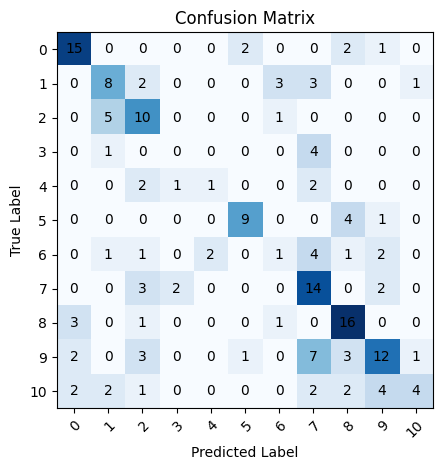

In [1241]:
cm = confusion_matrix(y_test, y_pred)
class_names = best_model.classes_
tick_marks = np.arange(len(class_names))

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
# plt.colorbar()
plt.xticks(tick_marks, class_names, rotation=45, ha="right", rotation_mode="anchor")
plt.yticks(tick_marks, class_names)

# Values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], "d"),
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Node classification

In [1242]:
def visualize_(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

def visualize(h, color, class_names):
    z = TSNE(n_components=2, random_state=42).fit_transform(
        h.detach().cpu().numpy()
    )

    color = np.asarray(color)
    class_names = np.asarray(class_names)

    plt.figure(figsize=(10, 10))

    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=color,
        cmap="tab20",
        s=70,
        alpha=0.8,
    )

    plt.xticks([])
    plt.yticks([])

    # Obtener una etiqueta por clase
    unique_classes = np.unique(color)
    handles = scatter.legend_elements()[0]

    labels = [
        class_names[color == c][0]
        for c in unique_classes
    ]

    plt.legend(
        handles,
        labels,
        title="Node types",
        loc="best"
    )

    plt.tight_layout()
    plt.show()
    
# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

In [1243]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### Preprocessing

##### Option 1 (partial correlations)

In [ ]:
# Partial correlation

""" df_matrix = pg.pcorr(df_join_raw_intensity)
df_matrix """


from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
scaler = StandardScaler()

df_subgroup_scaled = scaler.fit_transform(df_join_raw_intensity)
lw = LedoitWolf()
lw.fit(df_subgroup_scaled)

# Matriz de covarianza regularizada
cov = lw.covariance_
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
df_matrix = pd.DataFrame(corr)
df_matrix

In [ ]:
# Edge list

threshold = np.percentile(np.abs(df_matrix), 3) # Important

df_weighted_edges = (df_matrix.where(np.triu(np.ones(df_matrix.shape), k=1).astype(bool)).stack())
df_weighted_edges = df_weighted_edges.dropna().to_frame()
df_weighted_edges.reset_index(inplace=True)
df_weighted_edges.columns = ["source", "target", "weight"]
df_weighted_edges = df_weighted_edges[df_weighted_edges["weight"].abs() >= threshold]
df_weighted_edges


In [ ]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

##### Option 2 (K-NN)

In [1244]:
df_join_raw_intensity

,AR_2.131,AR_2.132,AR_2.133,AR_2.134,AR_2.135,AR_2.136,AR_2.137,AR_2.138,AR_2.139,AR_2.140,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
3072,5.130166,5.343628,5.317453,5.070158,5.267546,4.791498,4.826269,4.709920,4.901736,4.663130,...,3.515879,4.655424,4.505656,4.877023,3.948441,4.629174,4.375918,4.861519,3.580755,4.377145
5122,5.023015,5.214261,4.504189,4.882667,4.827848,5.628397,5.379179,5.029880,5.413043,4.889224,...,5.299280,5.297026,5.129695,5.221422,5.523984,5.176126,6.101565,6.063022,6.710662,6.850332
1026,3.973825,3.185309,3.335007,3.552610,4.014149,3.590505,2.570359,3.350594,3.360789,2.905322,...,2.742990,3.291870,3.871651,3.561956,2.809524,3.210722,3.147984,3.693127,2.963590,2.797572
3077,5.170928,5.450149,5.500358,5.041154,5.545196,5.294520,5.126694,5.038237,5.223161,5.022871,...,4.645517,5.183908,4.803662,5.280668,4.724810,5.348147,4.559819,5.253153,4.637466,5.328960
5127,-0.078472,2.151233,-0.076437,2.551387,-0.074404,-0.060242,-0.052200,1.711733,-0.046193,-0.042199,...,-0.766233,3.408366,1.157124,2.725741,-0.506380,-0.694769,-0.592521,2.760075,-0.595404,-0.691628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,0.642668,3.972674,2.524512,0.649303,0.652617,0.679046,0.688919,0.692206,0.705330,0.711879,...,-0.857745,-0.730518,-0.226158,-0.719781,-0.234996,-0.741305,-0.475540,-0.714431,-0.490117,-0.735905
4071,-0.296947,-0.294894,1.884207,2.618649,1.758578,1.886468,-0.284679,-0.282646,-0.280616,1.985983,...,-0.735712,-0.680897,1.278688,1.799632,-0.515230,-0.686831,-0.612402,-0.677944,1.849813,-0.683859
5106,1.577677,1.580361,1.583041,2.734886,1.588387,3.477108,1.606966,3.286745,3.577443,3.896404,...,0.421030,0.526989,0.879426,3.879926,0.870412,0.514362,0.751116,0.533242,0.735883,0.520696
2038,3.133821,3.136552,3.139282,3.144736,3.147460,3.169196,3.180026,3.182729,3.193528,3.198917,...,1.824945,1.930891,2.349012,1.939478,2.341842,1.922269,2.204549,1.943758,2.131944,1.926584


In [1245]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,3072,5122,1026,3077,5127,1032,8,4107,2065,1042,...,1994,3020,4060,992,3040,2019,4071,5106,2038,4088
AR_2.131,5.130166,5.023015,3.973825,5.170928,-0.078472,3.570346,1.514461,3.714534,2.178250,5.601956,...,3.087355,4.434302,2.539398,5.234197,3.939224,0.642668,-0.296947,1.577677,3.133821,-0.349213
AR_2.132,5.343628,5.214261,3.185309,5.450149,2.151233,3.252927,1.515152,4.862798,2.180609,5.886869,...,0.868688,4.672941,2.620812,5.235591,4.083868,3.972674,-0.294894,1.580361,3.136552,-0.346635
AR_2.133,5.317453,4.504189,3.335007,5.500358,-0.076437,3.309953,2.700345,3.391382,2.767318,5.391767,...,0.871968,4.493782,2.411913,5.014199,4.048461,2.524512,1.884207,1.583041,3.139282,1.507120
AR_2.134,5.070158,4.882667,3.552610,5.041154,2.551387,3.530824,2.696647,3.395092,2.185318,5.288866,...,0.878522,4.445350,2.541182,4.997008,4.107328,0.649303,2.618649,2.734886,3.144736,1.524976
AR_2.135,5.267546,4.827848,4.014149,5.545196,-0.074404,2.903310,2.468783,3.396943,2.187669,5.661263,...,0.881796,4.577336,2.545580,5.294633,4.175661,0.652617,1.758578,1.588387,3.147460,-0.341495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PD_2.48,4.629174,5.176126,3.210722,5.348147,-0.694769,1.802637,1.490460,4.514401,1.287676,5.832258,...,-0.611793,4.448713,1.964852,5.352844,3.905636,-0.741305,-0.686831,0.514362,1.922269,2.476524
PD_2.49,4.375918,6.101565,3.147984,4.559819,-0.592521,2.403645,1.518535,2.821858,1.466230,5.672577,...,-0.340107,4.034962,2.093501,4.685044,3.381617,-0.475540,-0.612402,0.751116,2.204549,2.721286
PD_2.50,4.861519,6.063022,3.693127,5.253153,2.760075,3.508977,3.177941,2.672112,1.309898,5.527432,...,-0.585312,4.274298,1.978055,4.909329,3.802172,-0.714431,-0.677944,0.533242,1.943758,2.684167
PD_2.51,3.580755,6.710662,2.963590,4.637466,-0.595404,1.823644,1.517598,2.811304,1.454604,5.823318,...,-0.354444,3.985916,2.088688,4.809423,2.555082,-0.490117,1.849813,0.735883,2.131944,-0.969165


In [1246]:
X = df_join_raw_intensity_t.values
X

array([[ 5.13016579,  5.0230154 ,  3.97382524, ...,  1.577677  ,
         3.1338214 , -0.34921315],
       [ 5.34362828,  5.21426117,  3.18530933, ...,  1.580361  ,
         3.13655246, -0.34663498],
       [ 5.31745318,  4.50418922,  3.33500694, ...,  1.58304068,
         3.13928185,  1.50711973],
       ...,
       [ 4.86151904,  6.06302239,  3.69312715, ...,  0.53324174,
         1.94375763,  2.6841666 ],
       [ 3.58075506,  6.71066212,  2.96358962, ...,  0.73588304,
         2.13194355, -0.9691646 ],
       [ 4.37714525,  6.8503317 ,  2.79757227, ...,  0.52069596,
         1.9265842 , -1.01205228]])

In [1247]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_join_raw_intensity_t.values)
X_scaled

array([[ 1.19492252, -0.46707419,  0.67731183, ..., -0.26003897,
         1.01761194, -0.82195578],
       [ 1.83082722,  0.08469213, -0.73013355, ..., -0.25771101,
         1.02229063, -0.82010492],
       [ 1.7528516 , -1.96394813, -0.46293386, ..., -0.25538681,
         1.02696645,  0.51069325],
       ...,
       [ 0.39462394,  2.53346706,  0.1762855 , ..., -1.16592388,
        -1.02113512,  1.35568736],
       [-3.42077163,  4.40198311, -1.12588761, ..., -0.99016411,
        -0.6987461 , -1.26701479],
       [-1.04832547,  4.80494612, -1.4222169 , ..., -1.17680539,
        -1.05055562, -1.29780357]])

In [1248]:
# similarity = cosine_similarity(X_scaled)
# similarity

In [1249]:
# Similarity matrix

k = 10 # Change

A = kneighbors_graph(
    X_scaled, # X, X_scaled
    n_neighbors=k,
    metric="cosine",
    mode="distance",
    include_self=False
)
A.toarray()

array([[0.        , 0.57101618, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.42172772],
       [0.        , 0.        , 0.        , ..., 0.504236  , 0.42172772,
        0.        ]])

In [1250]:
# Edge list

edges = []

n = A.shape[0]

for i in range(n):
    for j in range(i + 1, n): # Solo parte superior (grafo no dirigido)
        if A[i, j] != 0:
            edges.append((i, j, A[i, j]))

print(edges)

df_weighted_edges = pd.DataFrame(edges, columns=["source", "target", "weight"])
df_weighted_edges

[(0, 1, 0.571016176263828), (0, 4, 0.5626483734249783), (0, 13, 0.5487247832742445), (0, 83, 0.5591084721748582), (0, 91, 0.5375899359194781), (0, 416, 0.43758129935600876), (0, 417, 0.5275970490657874), (0, 426, 0.5244316639438089), (0, 837, 0.5530117289374027), (0, 839, 0.5494442898634462), (1, 8, 0.34682866004346036), (1, 11, 0.3135114677073927), (1, 85, 0.41889085012150706), (1, 89, 0.4087685773551488), (1, 279, 0.39978480820451734), (1, 316, 0.4007005362939968), (1, 377, 0.40879798784521904), (1, 419, 0.3746080024138001), (1, 420, 0.36927085425122996), (1, 839, 0.4004642972310427), (2, 4, 0.5002706587420911), (2, 14, 0.4210049003453351), (2, 16, 0.4918896345715744), (2, 82, 0.3754981231239696), (2, 275, 0.473129980954474), (2, 300, 0.459751307322527), (2, 317, 0.5028866205451004), (2, 353, 0.4806576245467792), (2, 416, 0.5026235999619697), (2, 428, 0.44393412518983166), (3, 78, 0.4651389528802874), (3, 82, 0.4783016697736502), (3, 275, 0.4030646947566807), (3, 278, 0.2905456037826

,source,target,weight
0,0,1,0.571016
1,0,4,0.562648
2,0,13,0.548725
3,0,83,0.559108
4,0,91,0.537590
...,...,...,...
4305,882,883,0.323601
4306,882,886,0.510248
4307,884,886,0.434844
4308,884,887,0.580948


#### Data preparation

In [1251]:
df_weighted_edges

,source,target,weight
0,0,1,0.571016
1,0,4,0.562648
2,0,13,0.548725
3,0,83,0.559108
4,0,91,0.537590
...,...,...,...
4305,882,883,0.323601
4306,882,886,0.510248
4307,884,886,0.434844
4308,884,887,0.580948


In [1252]:
edge_index = torch.tensor(df_weighted_edges.iloc[:, [0, 1]].values, dtype=torch.long)

data = Data(edge_index=edge_index.t().contiguous())

num_nodes = data.num_nodes
x = torch.eye(num_nodes, dtype=torch.float)
# x = torch.tensor(X_scaled, dtype=torch.float)
data.x = x

y = torch.tensor(pd.Series(groups_id).astype("category").cat.codes.values, dtype=torch.long)
data.y = y

# 2. Obtener los índices de todos los nodos en formato numpy
node_indices = torch.arange(num_nodes).numpy()
labels = data.y.numpy()

# 3. Dividir los índices usando sklearn (80% entrenamiento, 20% prueba)
# Puedes usar "stratify=labels" si quieres mantener la proporción de clases
train_idx, test_idx = train_test_split(
    node_indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# 4. Crear las máscaras booleanas vacías (en falso)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 5. Cambiar a True las posiciones correspondientes a cada conjunto
train_mask[train_idx] = True
test_mask[test_idx] = True

# 6. Asignar las máscaras al objeto Data de PyTorch Geometric
data.train_mask = train_mask
data.test_mask = test_mask
data

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])


Data(edge_index=[2, 4310], x=[888, 888], y=[888], train_mask=[888], test_mask=[888])

In [1253]:
print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(edge_index=[2, 4310], x=[888, 888], y=[888], train_mask=[888], test_mask=[888])

Number of nodes: 888
Number of edges: 4310
Average node degree: 4.85
Number of training nodes: 710
Training node label rate: 0.80
Contains isolated nodes: True
Contains self-loops: False
Is undirected: False


In [1254]:
transform = T.Compose([T.ToUndirected()])#, T.AddSelfLoops()])
data = transform(data) 

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(edge_index=[2, 8620], x=[888, 888], y=[888], train_mask=[888], test_mask=[888])

Number of nodes: 888
Number of edges: 8620
Average node degree: 9.71
Number of training nodes: 710
Training node label rate: 0.80
Contains isolated nodes: True
Contains self-loops: False
Is undirected: True


In [1255]:
data.x.shape, data.x.size(-1), data.num_features

(torch.Size([888, 888]), 888, 888)

In [1256]:
num_features = data.num_features # data.x.size(-1)

# 2. Obtener el número de clases (valores únicos en el tensor y)
if data.y.dim() <= 1:
    # Para clasificación de nodos o grafos con etiquetas discretas
    num_classes = int(data.y.max()) + 1
else:
    # Para etiquetas representadas en formato one-hot o multi-label
    num_classes = data.y.size(-1)

print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Number of features: 888
Number of classes: 11


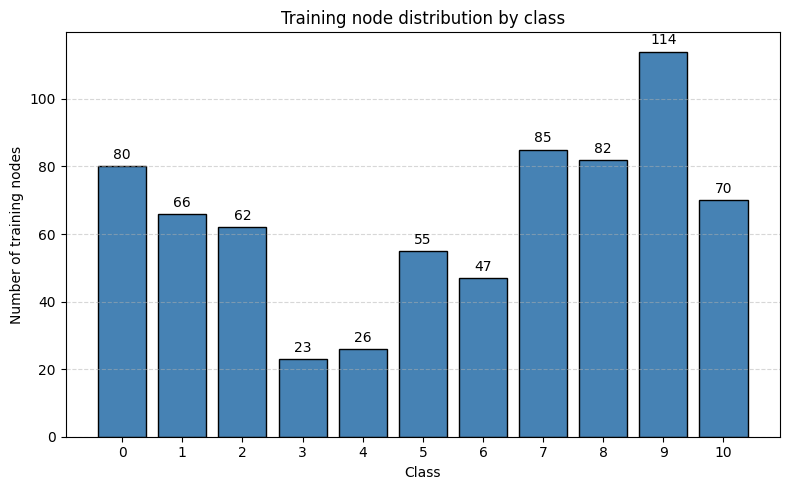

In [1257]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
    data.y[data.train_mask],
    return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    classes.astype(str),
    counts,
    color="steelblue",
    edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=10,
    # fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Training node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

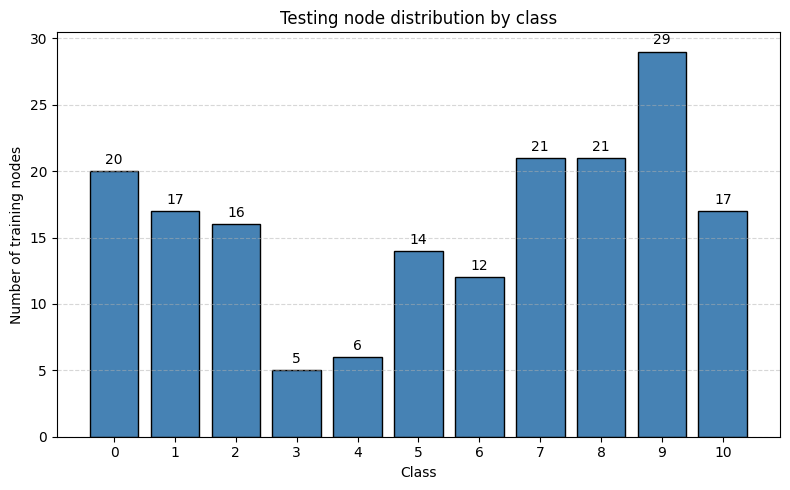

In [1258]:
# Número de nodos por clase en el conjunto de entrenamiento
unique, counts = torch.unique(
    data.y[data.test_mask],
    return_counts=True
)

classes = unique.cpu().numpy()
counts = counts.cpu().numpy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    classes.astype(str),
    counts,
    color="steelblue",
    edgecolor="black"
)

# Mostrar el número de nodos sobre cada barra
plt.bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=10,
    # fontweight="bold"
)

plt.xlabel("Class")
plt.ylabel("Number of training nodes")
plt.title("Testing node distribution by class")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### GCN

In [1259]:
# Define GCN

class GCN(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes):
        super(GCN, self).__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(num_features, 1024)
        self.conv2 = GCNConv(1024, 128)
        self.conv3 = GCNConv(128, dim_h)
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space

        # Prediction head: linear classifier
        out = self.classifier(z)

        return out, z

# Hyperparameters
dimension = 128 # dimension of node embeddings
number_features = num_features # dimension of node features
number_classes = num_classes # number of classes

model = GCN(num_features=number_features, dim_h=dimension, num_classes=number_classes)
print(model)

GCN(
  (conv1): GCNConv(888, 1024)
  (conv2): GCNConv(1024, 128)
  (conv3): GCNConv(128, 128)
  (classifier): Linear(in_features=128, out_features=11, bias=True)
)


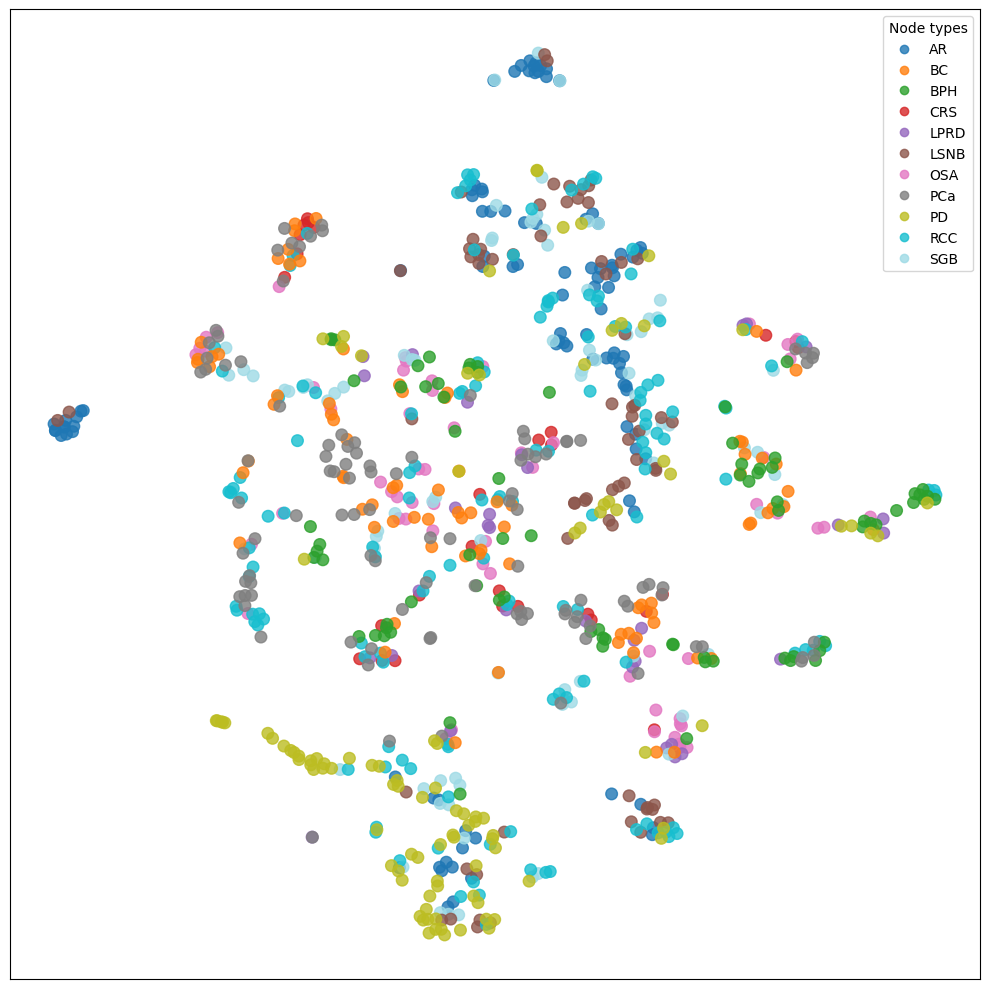

In [1260]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [1261]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    # loss = criterion(out, data.y)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(out.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

Epoch 1000 | Loss: 0.23 | Acc: 90.70%: 100%|██████████| 1000/1000 [00:21<00:00, 46.80it/s]


In [1262]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

Acc: 38.20%


In [1263]:
# Get node embeddings
print(z.shape)
z

torch.Size([888, 128])


tensor([[1.9509, 3.7992, 1.3796,  ..., 2.9342, 1.5407, 3.6335],
        [3.4135, 4.4835, 1.6796,  ..., 3.2833, 2.7222, 4.2748],
        [1.8915, 4.4881, 2.3626,  ..., 3.2405, 2.2758, 4.2047],
        ...,
        [0.2985, 5.2103, 0.9795,  ..., 4.4765, 0.1206, 5.1401],
        [1.4278, 4.4838, 3.8063,  ..., 3.5510, 2.6244, 3.6405],
        [0.5690, 3.3413, 0.7910,  ..., 1.7869, 0.2014, 3.5708]],
       grad_fn=<ReluBackward0>)

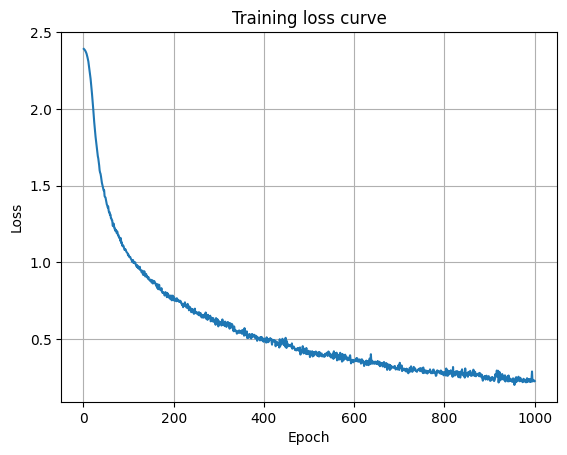

In [1264]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

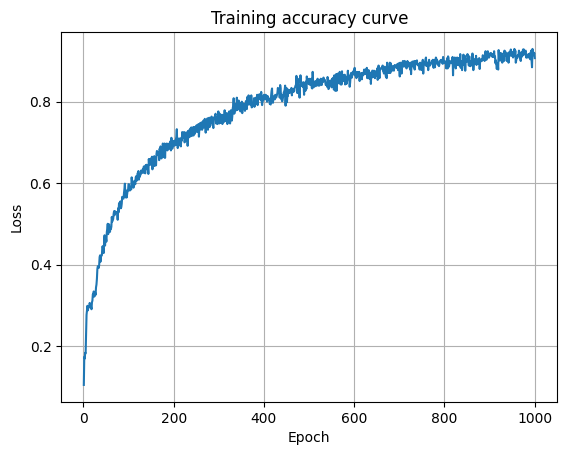

In [1265]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

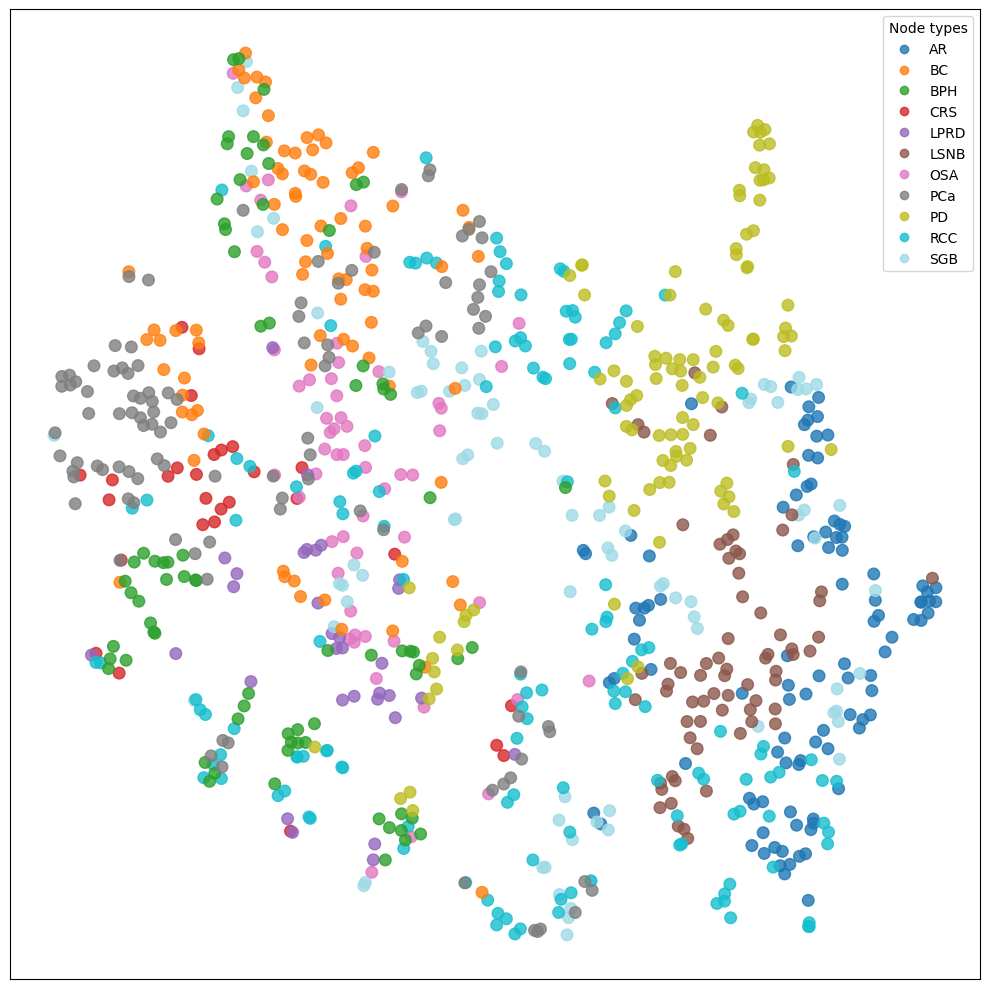

In [1266]:
visualize(z, data.y, groups_id)

#### GAT

In [1267]:
# Define GAT
class GAT(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes, heads=1):
        super(GAT, self).__init__()
        torch.manual_seed(42)
        # GAT layers
        """ self.conv1 = GATv2Conv(num_features, 512, heads=heads)
        self.conv2 = GATv2Conv(512 * heads, 64, heads=heads)
        self.conv3 = GATv2Conv(64 * heads, dim_h, heads=1) """
        
        """ self.conv1 = GATv2Conv(num_features, 64, heads=4)
        self.conv2 = GATv2Conv(64 * 4, 64, heads=4)
        self.conv3 = GATv2Conv(64 * 4, dim_h, heads=1) """
        
        self.conv1 = GATv2Conv(
            num_features,
            64,
            heads=4,
            dropout=0.6
        )

        self.conv2 = GATv2Conv(
            64 * 4,
            dim_h,
            heads=1,
            concat=False,
            dropout=0.6
        )
        
        # Prediction head
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        """ h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space """
        
        """ h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        z = self.conv3(h, edge_index) """
        
        """ x = F.dropout(x, 0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, 0.6, training=self.training)
        z = self.conv2(x, edge_index) """
        
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training=self.training)
        h = self.conv2(h, edge_index)
        z = F.elu(h)
        
        # Prediction head: linear classifier
        out = self.classifier(z)
        return out, z

# Hyperparameters
dimension = 128 # node embedding dimension d'
num_features = num_features # input feature dimension d
num_classes = num_classes # number of output classes |Y|
num_heads = 2 # number of attention heads K

# Model instantiation
model = GAT(
    num_features = num_features,
    dim_h        = dimension,
    num_classes  = num_classes,
    heads        = num_heads
)
print(model)

GAT(
  (conv1): GATv2Conv(888, 64, heads=4)
  (conv2): GATv2Conv(256, 128, heads=1)
  (classifier): Linear(in_features=128, out_features=11, bias=True)
)


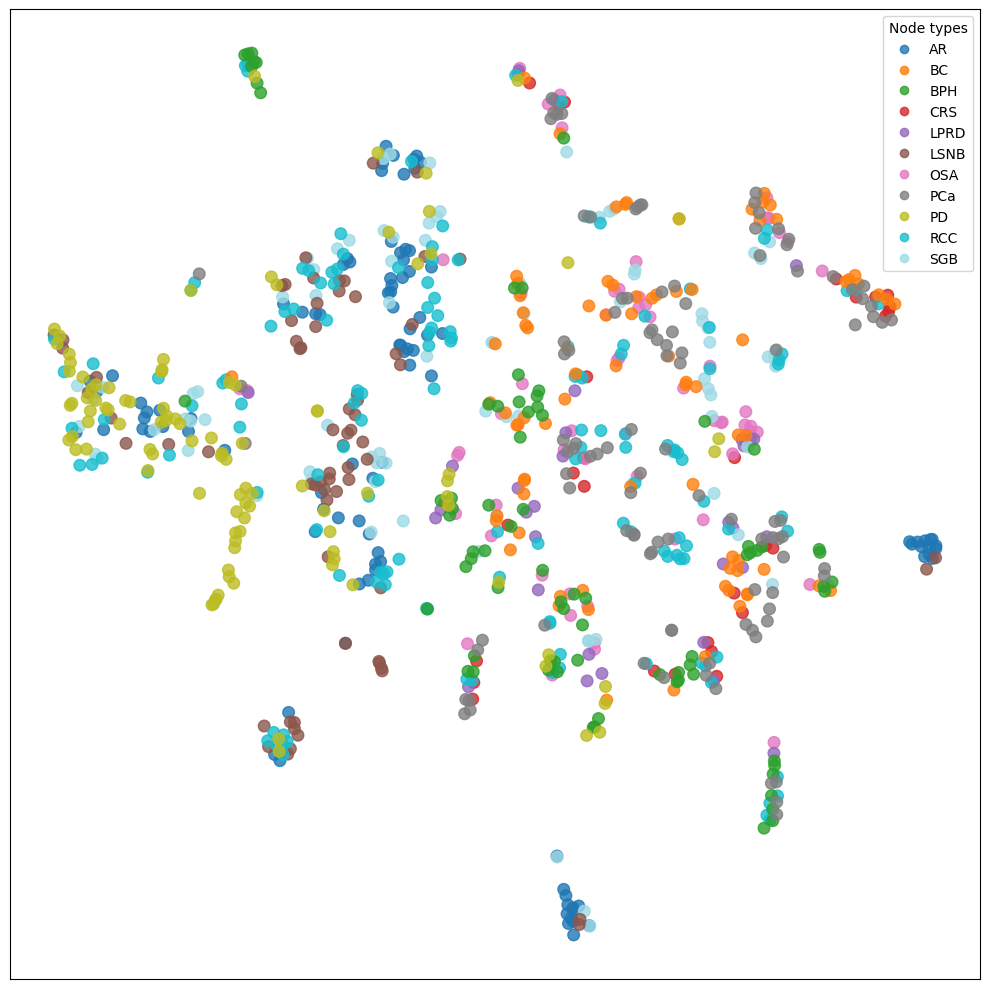

In [1268]:
# Vizualization
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [1269]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()

    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(z.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

Epoch 1000 | Loss: 0.66 | Acc: 75.49%: 100%|██████████| 1000/1000 [00:18<00:00, 52.93it/s]


In [1270]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

Acc: 37.08%


Confusion Matrix:
 [[ 8  0  0  0  0  4  0  0  1  1  6]
 [ 0  8  0  0  0  0  4  3  0  1  1]
 [ 0  3 11  0  0  0  0  0  1  0  1]
 [ 0  2  1  0  0  0  0  2  0  0  0]
 [ 0  1  1  0  1  0  0  0  0  3  0]
 [ 2  0  0  0  0  7  0  0  4  1  0]
 [ 0  1  0  1  2  1  3  1  1  1  1]
 [ 0  3  2  2  2  0  0  6  0  6  0]
 [ 4  0  1  0  0  0  0  0 12  3  1]
 [ 2  0  5  2  0  2  2  1  3  9  3]
 [ 5  1  1  0  0  0  1  3  0  5  1]]


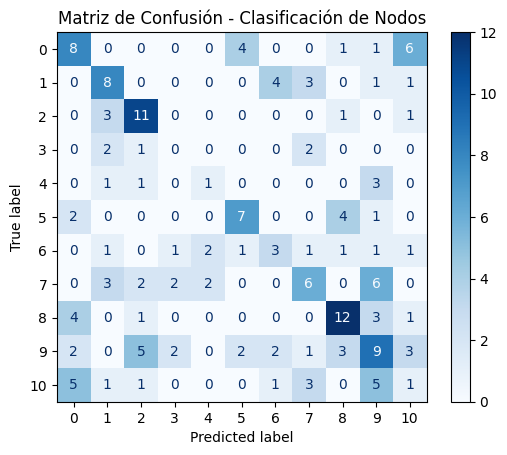

In [1282]:
model.eval()
with torch.no_grad():
    # 2. Obtener las predicciones del modelo (log_softmax o logits)
    out, z = model(data.x, data.edge_index)
    
    # 3. Convertir las salidas en las clases predichas (índice con mayor valor)
    y_pred = out.argmax(dim=1)

# 4. Filtrar solo los nodos del conjunto de prueba (Test Set)
# Usamos .cpu().numpy() porque scikit-learn trabaja con vectores de NumPy
y_true_test = data.y[data.test_mask].cpu().numpy()
y_pred_test = y_pred[data.test_mask].cpu().numpy()

# 5. Calcular la matriz de confusión numérica
cm = confusion_matrix(y_true_test, y_pred_test)
print("Confusion Matrix:\n", cm)

labels = [f"{i}" for i in range(out.shape[1])] 

disp = ConfusionMatrixDisplay(confusion_matrix=cm) # , display_labels=labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matriz de Confusión - Clasificación de Nodos")
plt.show()

In [1271]:
# Get node embeddings
print(z.shape)
z

torch.Size([888, 128])


tensor([[-0.1229,  0.2508, -0.0924,  ...,  0.2003, -0.1063, -0.2959],
        [-0.0885,  0.1782, -0.0807,  ...,  0.2145, -0.0537, -0.2781],
        [-0.0060, -0.3425,  0.2094,  ...,  0.2579,  0.0096, -0.0282],
        ...,
        [ 0.1158,  0.3951,  0.2503,  ...,  0.3741,  0.0490,  0.1219],
        [ 0.1529,  0.5393, -0.0295,  ...,  0.3400,  0.1692,  0.0857],
        [ 0.1199, -0.0948,  0.2548,  ...,  0.3425,  0.0444, -0.0264]],
       grad_fn=<EluBackward0>)

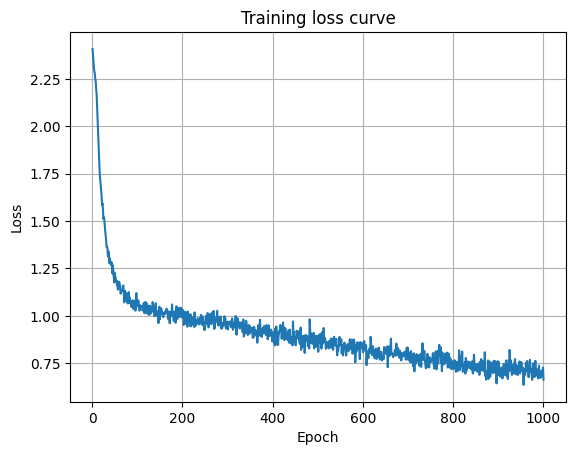

In [1272]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

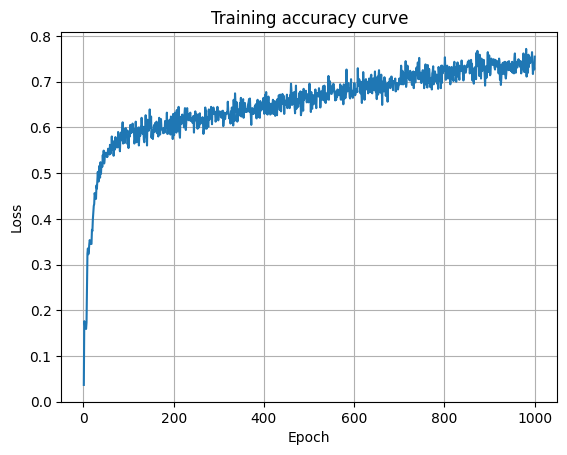

In [1273]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

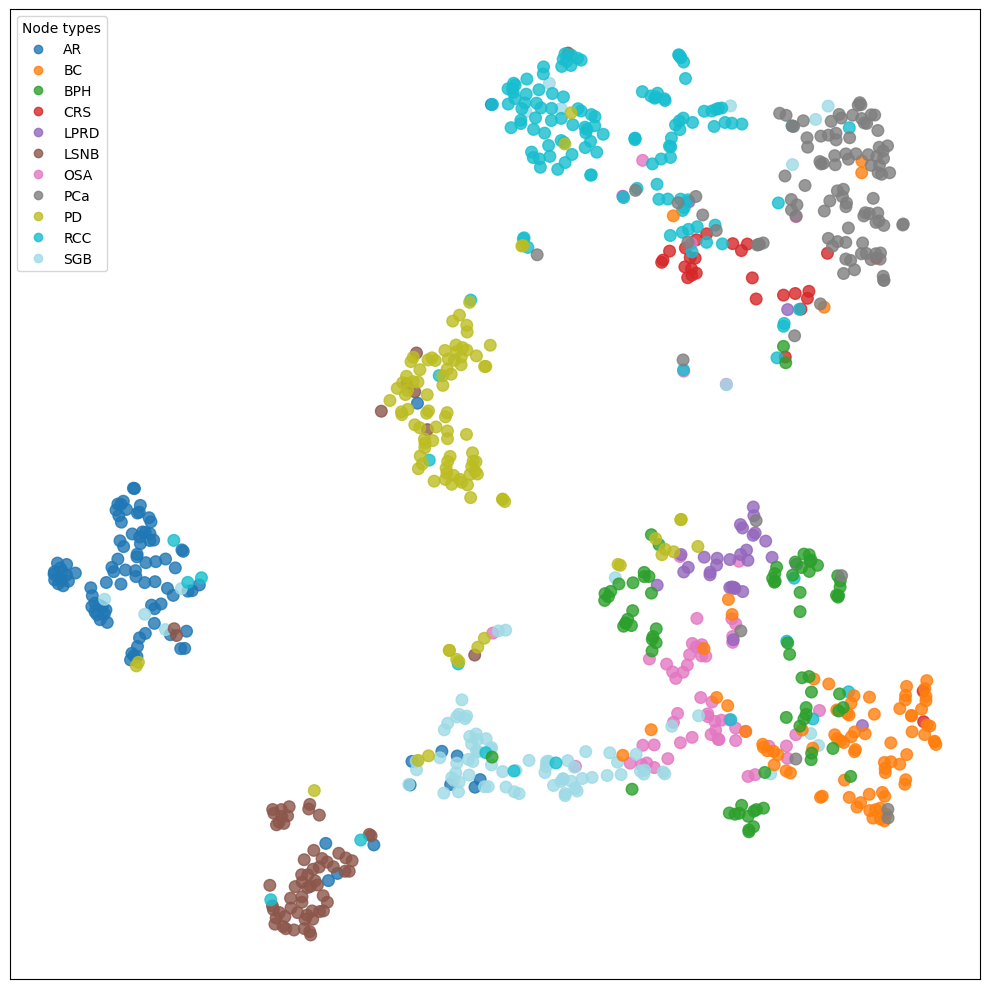

In [1274]:
visualize(z, data.y, groups_id)